# Do open concepts spread across more fields? RQ2-D1 screen test (demo)

This notebook is a runnable demo of the **`models` stage** of the RQ2-D1 experiment (`method.py --stage models`).

**Question.** Take an emerging research concept (e.g. *"einstein podolsky rosen steering"*) at focal year *t*. Does its
**neighbourhood openness** in the evolving co-word network predict how far its papers spread across disciplines in the
next five years, W2 = [t+1, t+5]? The prediction must hold *beyond* the standard baselines: level, volume, momentum,
burst, diversity and coherence.

**What the full pipeline does.** `method.py` orchestrates 12 stages: vendor tests, population, prep, attach,
indicators, openness, features, outcomes, models, power, freeze and outputs. The early stages build co-word snapshots
and ego networks from a 462,812-work corpus, which cannot be rerun in a notebook. They produce one analysis table with
one row per (concept, t):

* **openness at t**, measured in three ways:
  * `closure_res`: top-20 Chung-Lu closure, residualised on turnover, volume, age and W1 entropy.
  * `closure_res_imp`: the imputed co-primary version of `closure_res`.
  * Burt `constraint`, effective size `esize_norm`, and excess cross-community pairs `xcomm_exc`.
* **W1 baselines (BASE):** W1 entropy, active subfields, log volume, momentum, growing-edge breadth, Kleinberg
  burst, Rafols coherence, P_rar, plus origin, F-band, route and year dummies.
* **W2 outcomes:** rarefied Shannon change `Y1r`, Rao-Stirling change `Y2`, and `log1p_Y3`, the new subfields
  reached by author-disjoint newcomers.

This demo loads a **100-concept subset** of that table from `mini_demo_data.json` and runs the original
`models.py` code on it. That code is:

1. OLS `Y ~ BASE + openness_z` with a concept-cluster bootstrap, CR1 SEs, and Holm correction over the 3 outcomes.
2. Grouped-by-concept CV ΔR² (FULL − BASE).
3. The pre-declared verdict rule.
4. The within-E_up subset, the robustness grid, mediation, partial dependence, a volume check with VIF, and sanity checks.

The full run (138 MAIN concepts, B = 2000) returned **D1_NOT_SUPPORTED_SCREEN**. Because this demo uses a 100-concept
subset, its numbers will differ somewhat from the paper's.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install
_pip('loguru==0.7.3')

# numpy, pandas, scipy, statsmodels, matplotlib, pyarrow — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'statsmodels==0.14.6', 'matplotlib==3.10.0',
         'pyarrow==18.1.0')

## Imports

These are the original import blocks of `method.py`, `models.py` and `stats_core.py`. They include `method.py`'s
single-thread BLAS setting: the models solve many small dense least-squares problems, and BLAS threading makes those
much slower. `matplotlib` and `types` are added for the notebook.

In [2]:
from __future__ import annotations

import os
import sys

for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):
    os.environ.setdefault(_v, "1")  # small dense solves: BLAS threading is ~1000x slower here
import time
import json
import math
import types
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
from loguru import logger
from scipy import stats

import matplotlib.pyplot as plt  # notebook addition (visualisation)

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_WV-8ZZxjzY5t/round-3/experiment-6/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print("concepts:", len(data["examples"]), "| concept-year rows:", sum(len(e["feature_rows"]) for e in data["examples"]))
print("example concept:", data["examples"][0]["concept_id"], "-", data["examples"][0]["phrase"],
      "| first row keys:", list(data["examples"][0]["feature_rows"][0])[:12], "...")

D1 screen panel subset: 100 concepts (90 MAIN, 10 SENSITIVITY-only), seeded sample. Each example = one concept with its per-(concept, t) W1 features + openness (feature_rows), W2 outcomes (outcome_rows) and its E_up label (onset/group, null if never E_up).
concepts: 100 | concept-year rows: 399
example concept: c_007a7950eb4d - dantzig selector | first row keys: ['concept_id', 't', 'n_W1', 'n_W1_known', 'RS_W1', 'n_active_W1', 'log_vol_W1', 'momentum', 'GEB', 'n_growing', 'rafols_coh', 'n_flows'] ...


## Configuration

These are the tunable parameters. In the original, `run(boot=2000)` sets `B = boot` for the primary bootstrap and
`Bg = 1000` for the robustness grid; a `--mini` smoke run uses 200 and 200. `cv_one` repeats grouped 5-fold CV
20 times. The sanity checks use 200 placebo permutations, 10 label shuffles, 5 CV repeats, and bootstrap sizes of
1000 and 2000.

The models stage runs in about a minute even at the original sizes, so the cell below uses the **original values**.
A quicker smoke setting is given in the comment.

In [5]:
B_BOOT = 2000          # cluster-bootstrap draws for primary OLS / CV dR2 / E_up / mediation (original: 2000; --mini: 200)
BG_BOOT = 1000         # cluster-bootstrap draws per robustness-grid spec (original: 1000; --mini: 200)
CV_REPS = 20           # repeats of grouped 5-fold CV in cv_one (original: 20)
N_PLACEBO = 200        # sanity: within-year placebo permutations (original: 200)
N_SHUFFLE = 10         # sanity: label-shuffle CV runs (original: 10)
SANITY_CV_REPS = 5     # sanity: CV repeats for shuffle / leaky-feature checks (original: 5)
SANITY_BOOT = (1000, 2000)  # sanity: bootstrap-stability comparison sizes (original: (1000, 2000))
# quick smoke settings (~10 s): B_BOOT=200, BG_BOOT=200, CV_REPS=5, N_PLACEBO=50, N_SHUFFLE=3, SANITY_CV_REPS=2, SANITY_BOOT=(250, 500)

## Shared helpers (`common.py`, vendored `lib_metrics.py`)

This section copies the helpers the models stage uses:
* `write_json` and its numpy-aware `_json_default` from `common.py`.
* `holm` and `bh` from the vendored iteration-2 `lib_metrics.py`.

The original modules are imported as `K` (common) and `lm` (lib_metrics). The notebook builds namespaces with the
same names so the model code below can stay unchanged. Outputs go to a local `demo_outputs/` folder.

In [6]:
OUT = Path("demo_outputs") / "results"   # original: <repo>/results
WORK = Path("demo_outputs") / "work"     # original: <repo>/work (only used by the fold-internal R1a variant)
OUT.mkdir(parents=True, exist_ok=True)

# --- from common.py
def write_json(p: Path, obj) -> None:
    p.parent.mkdir(parents=True, exist_ok=True)
    p.write_text(json.dumps(obj, indent=1, default=_json_default))


def _json_default(o):
    import numpy as np
    if isinstance(o, (np.bool_,)):
        return bool(o)
    if isinstance(o, (np.integer,)):
        return int(o)
    if isinstance(o, (np.floating,)):
        return None if not np.isfinite(o) else float(o)
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (set, frozenset)):
        return sorted(o)
    if isinstance(o, Path):
        return str(o)
    raise TypeError(type(o))


# --- from vendor/lib_metrics.py
def holm(pvals) -> list[float]:
    """Holm step-down adjusted p-values (NaN entries passed through)."""
    p = np.asarray(pvals, dtype=float)
    out = np.full_like(p, np.nan)
    ok = np.where(np.isfinite(p))[0]
    order = ok[np.argsort(p[ok])]
    m = len(order)
    running = 0.0
    for rank, idx in enumerate(order):
        adj = min(1.0, (m - rank) * p[idx])
        running = max(running, adj)
        out[idx] = running
    return out.tolist()


def bh(pvals) -> list[float]:
    """Benjamini-Hochberg q-values (NaN entries passed through)."""
    p = np.asarray(pvals, dtype=float)
    out = np.full_like(p, np.nan)
    ok = np.where(np.isfinite(p))[0]
    if ok.size == 0:
        return out.tolist()
    order = ok[np.argsort(p[ok])]
    m = len(order)
    q = p[order] * m / np.arange(1, m + 1)
    q = np.minimum.accumulate(q[::-1])[::-1]
    out[order] = np.minimum(q, 1.0)
    return out.tolist()


# --- from openness.py (R1a residualisation regressors; only used by the fold-internal variant)
R1A = ["new_relation_rate", "novelty", "beta_sim_rar", "log_vol3", "age"]

K = types.SimpleNamespace(write_json=write_json)   # stands in for `import common as K`
lm = types.SimpleNamespace(holm=holm, bh=bh)       # stands in for `import lib_metrics as lm`

## Model core (`stats_core.py`, verbatim)

These are the numpy-only model helpers:
* `design` builds `[const, openness, BASE numerics, drop-first dummies for origin / F-band / route / year]`. The
  openness variable is always column 1.
* `cr1` gives CR1 cluster-robust SEs, clustered by concept.
* `cluster_boot` resamples whole concepts with replacement and refits OLS.
* `grouped_cv` and `delta_r2_boot` compute the out-of-fold R² gain of FULL (BASE + openness) over BASE. Folds are
  grouped by concept, so no concept appears in both train and test.

In [7]:
NUM_BASE = ["H_W1", "n_active_W1", "log_vol_W1", "momentum", "GEB", "burst_state", "rafols_coh_f", "coh_missing",
            "P_rar_f", "P_rar_missing"]
CATS = ["origin_group", "F_band", "route", "t"]
TURNOVER = ["new_relation_rate", "novelty", "beta_sim_rar_f", "beta_sim_missing"]


def design(d: pd.DataFrame, lead: list[str], num: list[str] = NUM_BASE, cats: list[str] = CATS,
           levels: dict | None = None) -> tuple[np.ndarray, list[str], dict]:
    """[const, lead..., num..., drop-first dummies]; lead columns sit at positions 1..len(lead).

    `levels` (from a previous call) freezes dummy coding, e.g. for held-out rows.
    """
    cols = [np.ones(len(d))]
    names = ["const"]
    for c in lead + num:
        cols.append(d[c].astype(float).values)
        names.append(c)
    lv_out = {}
    for c in cats:
        vals = d[c].astype(str).values
        lv = levels[c] if levels is not None else sorted(set(vals))
        lv_out[c] = lv
        for v in lv[1:]:
            cols.append((vals == v).astype(float))
            names.append(f"{c}={v}")
    X = np.column_stack(cols)
    if levels is None:  # drop constant dummy / numeric columns (never const or lead)
        keep = [i for i in range(X.shape[1]) if i <= len(lead) or np.ptp(X[:, i]) > 0]
        X = X[:, keep]
        names = [names[i] for i in keep]
    return X, names, lv_out


def ols(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    return np.linalg.lstsq(X, y, rcond=None)[0]


def cr1(X: np.ndarray, y: np.ndarray, g: np.ndarray, beta: np.ndarray | None = None) -> tuple[np.ndarray, np.ndarray]:
    """Coefficients and CR1 cluster-robust SEs (Stata small-sample factor)."""
    beta = ols(X, y) if beta is None else beta
    u = y - X @ beta
    n, k = X.shape
    XtXi = np.linalg.pinv(X.T @ X)
    uniq, inv = np.unique(g, return_inverse=True)
    G = len(uniq)
    S = np.zeros((G, k))
    np.add.at(S, inv, X * u[:, None])
    meat = S.T @ S
    V = XtXi @ meat @ XtXi * (G / (G - 1)) * ((n - 1) / max(n - k, 1))
    return beta, np.sqrt(np.clip(np.diag(V), 0, None))


def blocks_of(g: np.ndarray) -> list[np.ndarray]:
    uniq, inv = np.unique(g, return_inverse=True)
    order = np.argsort(inv, kind="stable")
    cuts = np.cumsum(np.bincount(inv))[:-1]
    return np.split(order, cuts)


def cluster_boot(X: np.ndarray, y: np.ndarray, g: np.ndarray, B: int, seed: int, j: int | list = 1) -> np.ndarray:
    blocks = blocks_of(g)
    G = len(blocks)
    rng = np.random.default_rng(seed)
    jj = np.atleast_1d(j)
    out = np.empty((B, len(jj)))
    for b in range(B):
        idx = np.concatenate([blocks[k] for k in rng.integers(0, G, G)])
        out[b] = ols(X[idx], y[idx])[jj]
    return out[:, 0] if np.ndim(j) == 0 else out


def boot_summary(est: float, draws: np.ndarray) -> dict:
    B = len(draws)
    lo, hi = np.percentile(draws, [2.5, 97.5])
    n_le, n_ge = int(np.sum(draws <= 0)), int(np.sum(draws >= 0))
    p = min(1.0, 2 * min((n_le + 1) / (B + 1), (n_ge + 1) / (B + 1)))
    return dict(coef=float(est), ci_lo=float(lo), ci_hi=float(hi), p_boot=float(p), boot_sd=float(np.std(draws, ddof=1)))


def r2(y: np.ndarray, p: np.ndarray) -> float:
    sst = float(np.sum((y - y.mean()) ** 2))
    return float(1 - np.sum((y - p) ** 2) / sst) if sst > 0 else math.nan


def fold_assign(g: np.ndarray, k: int, seed: int) -> np.ndarray:
    """Concepts shuffled (seeded) then dealt round-robin into k folds (grouped K-fold with shuffled group order)."""
    uniq = np.unique(g)
    perm = np.random.default_rng(seed).permutation(uniq)
    f_of = {c: i % k for i, c in enumerate(perm)}
    return np.array([f_of[c] for c in g])


def grouped_cv(Xb: np.ndarray, Xf: np.ndarray | None, y: np.ndarray, g: np.ndarray, reps: int = 20, k: int = 5,
               xf_fn=None) -> tuple[np.ndarray, np.ndarray]:
    """OOF predictions (averaged over repeats) for BASE and FULL; xf_fn(train_mask) -> FULL design (fold-internal)."""
    n = len(y)
    pb, pf = np.zeros((reps, n)), np.zeros((reps, n))
    for r in range(reps):
        f = fold_assign(g, k, r)
        for i in range(k):
            tr, te = f != i, f == i
            pb[r, te] = Xb[te] @ ols(Xb[tr], y[tr])
            XF = xf_fn(tr) if xf_fn is not None else Xf
            pf[r, te] = XF[te] @ ols(XF[tr], y[tr])
    return pb.mean(0), pf.mean(0)


def delta_r2_boot(y: np.ndarray, pb: np.ndarray, pf: np.ndarray, g: np.ndarray, B: int, seed: int) -> dict:
    blocks = blocks_of(g)
    G = len(blocks)
    rng = np.random.default_rng(seed)
    d = np.empty(B)
    for b in range(B):
        idx = np.concatenate([blocks[k] for k in rng.integers(0, G, G)])
        d[b] = r2(y[idx], pf[idx]) - r2(y[idx], pb[idx])
    lo, hi = np.percentile(d, [2.5, 97.5])
    return dict(r2_base=r2(y, pb), r2_full=r2(y, pf), delta_r2=r2(y, pf) - r2(y, pb), ci_lo=float(lo), ci_hi=float(hi))


def t_p_two_sided(coef: float, se: float, df: int) -> float:
    if not (np.isfinite(se) and se > 0):
        return math.nan
    return float(2 * stats.t.sf(abs(coef / se), df))


# stands in for `import stats_core as S`
S = types.SimpleNamespace(NUM_BASE=NUM_BASE, CATS=CATS, TURNOVER=TURNOVER, design=design, ols=ols, cr1=cr1,
                          blocks_of=blocks_of, cluster_boot=cluster_boot, boot_summary=boot_summary, r2=r2,
                          fold_assign=fold_assign, grouped_cv=grouped_cv, delta_r2_boot=delta_r2_boot,
                          t_p_two_sided=t_p_two_sided)

## Loading the analysis panel (`models.load_panel`)

The original reads three files:
* `features_ct.parquet`: W1 baselines plus openness at t.
* `outcomes_ct.parquet`: W2 outcomes.
* `labels_screen.parquet`: E_up take-off labels.

Here the same three tables are rebuilt from `data`: each example holds `feature_rows`, `outcome_rows` and `label`.
The rest of `load_panel` is unchanged:
* It merges the three tables.
* It median-imputes `beta_sim_rar` and adds a missingness dummy.
* It attaches the E_up onset and adds a route-A flag.

`pop_mask` selects one of three populations:
* **MAIN**: the primary population.
* **STRICT**: a stricter grounding.
* **SENSITIVITY**: no grounding filters.

In [8]:
FDIR = OUT / "d1"
OUTCOMES = ["Y1r", "Y2", "log1p_Y3"]
RULE_TEXT = ("D1_SUPPORTED_SCREEN = exists Y in {Y1r, Y2, Y3}: coef(closure_res) < 0 AND bootstrap CI excludes 0 AND "
             "Holm-adjusted p < 0.05 AND grouped-CV delta-R2 CI lower bound > 0 for that same Y. Else "
             "D1_NOT_SUPPORTED_SCREEN. If the sibling RQ1 holds and D1 fails -> 'take-off correlate only'. Sign > 0 with CI "
             "excluding 0 -> 'closure predicts breadth in the OPPOSITE direction' (reported, rule not met).")
SEED = 20260929


def load_panel() -> pd.DataFrame:
    # original: F / O / lab = pd.read_parquet(features_ct / outcomes_ct / labels_screen); here rebuilt from `data`
    F = pd.DataFrame([r for e in data["examples"] for r in e["feature_rows"]])
    O = pd.DataFrame([r for e in data["examples"] for r in e["outcome_rows"]])
    d = F.merge(O, on=["concept_id", "t"], how="inner")
    assert len(d) == len(F)
    med = float(d.beta_sim_rar.median())
    d["beta_sim_missing"] = d.beta_sim_rar.isna().astype(float)
    d["beta_sim_rar_f"] = d.beta_sim_rar.fillna(med)
    lab = pd.DataFrame([e["label"] for e in data["examples"] if e["label"] is not None]).drop_duplicates("concept_id")
    d = d.merge(lab[["concept_id", "onset", "group"]].rename(columns={"onset": "E_up_onset", "group": "E_up_group"}),
                on="concept_id", how="left")
    d["E_up"] = d.E_up_onset.notna()
    d["routeA"] = (d.route == "A_openalex_native").astype(float)
    return d


def pop_mask(d: pd.DataFrame, pop: str) -> np.ndarray:
    return {"MAIN": d.in_MAIN, "STRICT": d.in_STRICT, "SENSITIVITY": d.in_SENSITIVITY}[pop].values.astype(bool)


def model_rows(d: pd.DataFrame, y: str, lead: list[str], num: list[str]) -> pd.DataFrame:
    cols = [y] + lead + num
    ok = np.isfinite(d[cols].astype(float).values).all(1)
    return d[ok].reset_index(drop=True)

## One OLS fit and one grouped-CV comparison (`fit_one`, `cv_one`)

`fit_one` runs complete-case OLS of `Y` on `openness + BASE`. It reports the openness coefficient with:
* a concept-cluster bootstrap CI and two-sided p_boot;
* a CR1 SE and a t-test p;
* the coefficient in SD(Y) units.

`cv_one` computes out-of-fold predictions for BASE and FULL under grouped CV, then gives a concept-bootstrap CI on
ΔR². The `foldwise=True` branch refits the R1a residualisation inside each training fold. It needs the full
`indicators_open.parquet`, which is not in the demo data, so the demo does not call it. Its code is kept unchanged.

In [9]:
def fit_one(d: pd.DataFrame, y: str, open_var: str, num: list[str] = S.NUM_BASE, B: int = 2000, seed: int = SEED,
            extra_lead: list[str] | None = None, cats: list[str] = S.CATS) -> dict:
    lead = [open_var] + (extra_lead or [])
    m = model_rows(d, y, lead, num)
    if m.concept_id.nunique() < 10:
        return dict(n_rows=len(m), n_concepts=int(m.concept_id.nunique()), coef=math.nan, note="too few concepts")
    X, names, _ = S.design(m, lead, num, cats)
    yy = m[y].astype(float).values
    g = m.concept_id.values
    beta, se = S.cr1(X, yy, g)
    draws = S.cluster_boot(X, yy, g, B, seed, 1)
    out = S.boot_summary(beta[1], draws)
    G = m.concept_id.nunique()
    out.update(se_cr1=float(se[1]), p_cr1=S.t_p_two_sided(beta[1], se[1], G - 1), n_rows=len(m), n_concepts=int(G),
               n_params=X.shape[1], sd_y=float(yy.std(ddof=1)), coef_in_sd_y=float(beta[1] / yy.std(ddof=1)))
    if extra_lead:
        for k, nm in enumerate(extra_lead, start=2):
            out[f"coef_{nm}"] = float(beta[k])
            out[f"se_cr1_{nm}"] = float(se[k])
    return out


def cv_one(d: pd.DataFrame, y: str, open_var: str, num: list[str] = S.NUM_BASE, B: int = 2000, reps: int = CV_REPS,
           foldwise: bool = False, seed: int = SEED + 7, extra_full: list[str] | None = None) -> dict:
    # reps: original default 20 (now CV_REPS from the config cell)
    lead = [open_var] + (extra_full or [])
    m = model_rows(d, y, lead, num)
    Xf, names, _ = S.design(m, lead, num)
    Xb = np.delete(Xf, list(range(1, 1 + len(lead))), axis=1)
    yy = m[y].astype(float).values
    g = m.concept_id.values
    xf_fn = None
    if foldwise:
        fitrows = pd.read_parquet(WORK / "indicators_open.parquet")
        fitrows = fitrows[(fitrows.fold == "screen") & fitrows.age.between(3, 8) & (fitrows.year <= 2015)]
        regs = R1A + ["H_W1"]
        FX = np.column_stack([np.ones(len(fitrows))] + [fitrows[c].astype(float).values for c in regs])
        Fy = fitrows.closure.astype(float).values
        fok = np.isfinite(FX).all(1) & np.isfinite(Fy)
        FX, Fy, Fc = FX[fok], Fy[fok], fitrows.concept_id.values[fok]
        MX = np.column_stack([np.ones(len(m))] + [m[c].astype(float).values for c in regs])
        My = m.closure.astype(float).values

        def xf_fn(tr: np.ndarray) -> np.ndarray:
            trc = set(g[tr])
            sel = np.isin(Fc, list(trc))
            b = S.ols(FX[sel], Fy[sel])
            X2 = Xf.copy()
            X2[:, 1] = My - MX @ b
            return X2
    pb, pf = S.grouped_cv(Xb, Xf, yy, g, reps=reps, xf_fn=xf_fn)
    out = S.delta_r2_boot(yy, pb, pf, g, B, seed)
    out.update(n_rows=len(m), n_concepts=int(m.concept_id.nunique()), foldwise=foldwise)
    return out, m.assign(oof_base=pb, oof_full=pf)

## Primary analysis and the pre-declared rule (`primary`, `evaluate_rule`)

`primary` fits 5 openness measures × 3 outcomes on the MAIN population. It applies Holm over the 3 outcomes within
each co-primary measure (`closure_res_z` and `closure_res_imp_z`), and BH over the secondary network measures
(`constraint_z` and `esize_norm_z`).

`evaluate_rule` checks the pre-declared rule for each outcome. The rule needs all four conditions:
* the coefficient is negative, so more closure means less breadth gain (the D1 direction);
* the bootstrap CI excludes 0;
* Holm-adjusted p < 0.05;
* the grouped-CV ΔR² CI lower bound is above 0.

In [10]:
def primary(d: pd.DataFrame, B: int) -> tuple[pd.DataFrame, pd.DataFrame, dict, dict]:
    dm = d[pop_mask(d, "MAIN")]
    coef_rows, cv_rows, oof = [], [], {}
    for ov in ["closure_res_z", "closure_res_imp_z", "constraint_z", "esize_norm_z", "xcomm_exc_z"]:
        for y in OUTCOMES:
            r = fit_one(dm, y, ov, B=B)
            coef_rows.append(dict(model="a_primary_OLS", population="MAIN", openness=ov, outcome=y, **r))
            c, m = cv_one(dm, y, ov, B=B)
            cv_rows.append(dict(model="b_grouped_cv", population="MAIN", openness=ov, outcome=y, **c))
            if ov in ("closure_res_z", "closure_res_imp_z"):
                oof[(ov, y)] = m
                # demo: the fold-internal R1a variant needs the full indicators_open.parquet (not in the demo data)
                # if ov == "closure_res_z":
                #     cfw, _ = cv_one(dm, y, ov, B=B, foldwise=True)
                #     cv_rows.append(dict(model="b_grouped_cv_foldwise_R1a", population="MAIN", openness=ov, outcome=y, **cfw))
            logger.info(f"{ov:>18} {y:>9}: coef {r['coef']:+.4f} [{r['ci_lo']:+.4f}, {r['ci_hi']:+.4f}] p_boot {r['p_boot']:.4f} "
                        f"n={r['n_rows']}/{r['n_concepts']} | dR2 {c['delta_r2']:+.4f} [{c['ci_lo']:+.4f}, {c['ci_hi']:+.4f}]")
    coef = pd.DataFrame(coef_rows)
    cv = pd.DataFrame(cv_rows)
    # multiplicity: Holm over the 3 outcomes within each co-primary measure; BH over the secondary measures
    coef["p_holm"] = np.nan
    coef["q_bh_secondary"] = np.nan
    for ov in ["closure_res_z", "closure_res_imp_z"]:
        mk = coef.openness == ov
        coef.loc[mk, "p_holm"] = lm.holm(coef.loc[mk, "p_boot"].tolist())
    mk = coef.openness.isin(["constraint_z", "esize_norm_z"])
    coef.loc[mk, "q_bh_secondary"] = lm.bh(coef.loc[mk, "p_boot"].tolist())
    return coef, cv, oof, {}


def evaluate_rule(coef: pd.DataFrame, cv: pd.DataFrame, ov: str) -> dict:
    per = {}
    for y in OUTCOMES:
        a = coef[(coef.openness == ov) & (coef.outcome == y) & (coef.model == "a_primary_OLS")].iloc[0]
        b = cv[(cv.openness == ov) & (cv.outcome == y) & (cv.model == "b_grouped_cv")].iloc[0]
        cond = dict(coef_negative=bool(a.coef < 0), ci_excludes_0=bool(a.ci_hi < 0 or a.ci_lo > 0),
                    holm_p_lt_005=bool(a.p_holm < 0.05), cv_delta_r2_ci_lo_gt_0=bool(b.ci_lo > 0))
        per[y] = dict(conditions=cond, met=all(cond.values()),
                      opposite_direction=bool(a.coef > 0 and a.ci_lo > 0),
                      coef=float(a.coef), ci=[float(a.ci_lo), float(a.ci_hi)], p_boot=float(a.p_boot),
                      p_holm=float(a.p_holm), delta_r2=float(b.delta_r2), delta_r2_ci=[float(b.ci_lo), float(b.ci_hi)])
    return per

## Secondary analyses (`within_eup`, `robustness`)

**Within E_up** keeps only concepts with a take-off (E_up) onset in 2015 or earlier, and only the rows from 3 years
before onset up to onset. The analysis is flagged *underpowered* when fewer than 30 concepts remain.

**Robustness grid.** For each of the 3 openness measures and 3 outcomes, it fits these 12 specifications:
* populations STRICT and SENSITIVITY;
* route A only, route B only, and a route interaction;
* hydration batch;
* one row per concept;
* a turnover-augmented baseline and an origin-proximity control;
* dropping sense-check failures.

It adds alternative outcomes (Y1, Y1r20, log1p_Y3b), alternative closure definitions, and a Poisson QMLE (PPML)
for the count outcome Y3.

In [11]:
def within_eup(d: pd.DataFrame, B: int) -> dict:
    dm = d[pop_mask(d, "MAIN") & d.E_up.values]
    dm = dm[(dm.t >= dm.E_up_onset - 3) & (dm.t <= dm.E_up_onset) & (dm.E_up_onset <= 2015)]
    res = dict(n_concepts=int(dm.concept_id.nunique()), n_rows=len(dm),
               rule="concepts with E_up onset <= 2015; rows t in [onset-3, onset], age 3..8, MAIN")
    res["underpowered"] = bool(res["n_concepts"] < 30)
    rows = []
    for ov in ["closure_res_z", "closure_res_imp_z", "constraint_z"]:
        for y in OUTCOMES:
            r = fit_one(dm, y, ov, B=B)
            try:
                c, _ = cv_one(dm, y, ov, B=B)
            except (np.linalg.LinAlgError, ValueError) as e:
                logger.warning(f"E_up CV failed {ov} {y}: {e}")
                c = {}
            rows.append(dict(openness=ov, outcome=y, **r, **{f"cv_{k}": v for k, v in c.items()}))
    res["estimates"] = rows
    res["label"] = "UNDERPOWERED - descriptive only" if res["underpowered"] else "secondary analysis"
    return res


def robustness(d: pd.DataFrame, B: int) -> pd.DataFrame:
    specs = []
    for ov in ["closure_res_z", "closure_res_imp_z", "constraint_z"]:
        for y in OUTCOMES:
            specs += [
                dict(spec="MAIN (primary)", pop="MAIN", ov=ov, y=y),
                dict(spec="STRICT", pop="STRICT", ov=ov, y=y),
                dict(spec="SENSITIVITY (all main arm)", pop="SENSITIVITY", ov=ov, y=y),
                dict(spec="route A only", pop="MAIN", ov=ov, y=y, filt=lambda x: x.route == "A_openalex_native"),
                dict(spec="route B only", pop="MAIN", ov=ov, y=y, filt=lambda x: x.route == "B_s2_index"),
                dict(spec="route interaction", pop="MAIN", ov=ov, y=y, inter="routeA"),
                dict(spec="iteration-1 concepts (hydration_batch iter1)", pop="MAIN", ov=ov, y=y, filt=lambda x: x.hydration_batch == "iter1"),
                dict(spec="newly hydrated concepts (iter2)", pop="MAIN", ov=ov, y=y, filt=lambda x: x.hydration_batch == "iter2"),
                dict(spec="one row per concept (first eligible t)", pop="MAIN", ov=ov, y=y, first=True),
                dict(spec="turnover-augmented baseline", pop="MAIN", ov=ov, y=y, num=S.NUM_BASE + S.TURNOVER),
                dict(spec="+ origin-subfield proximity", pop="MAIN", ov=ov, y=y, num=S.NUM_BASE + ["origin_prox_f", "prox_missing"]),
                dict(spec="drop sense_check_fail", pop="MAIN", ov=ov, y=y, filt=lambda x: ~x.sense_check_fail.astype(bool)),
            ]
        for y2 in ["Y1", "Y1r20", "log1p_Y3b"]:
            specs.append(dict(spec=f"alt outcome {y2}", pop="MAIN", ov=ov, y=y2))
    for y in OUTCOMES:
        specs += [dict(spec="closure_unres (no residualisation)", pop="MAIN", ov="closure_unres_z", y=y),
                  dict(spec="closure_res_H3 (3-yr H in R1a)", pop="MAIN", ov="closure_res_H3_z", y=y),
                  dict(spec="W1-mean closure_res over [t-2, t]", pop="MAIN", ov="closure_res_w1mean_z", y=y),
                  dict(spec="xcomm_exc (cross-community pairs)", pop="MAIN", ov="xcomm_exc_z", y=y)]
    d = d.copy()
    d["log1p_Y3b"] = np.log1p(d.Y3b)
    if "Y1r20" not in d.columns:
        d["Y1r20"] = d.filter(regex=r"^Y1r\d+$").iloc[:, 0]
    rows = []
    for k, s in enumerate(specs):
        x = d[pop_mask(d, s["pop"])]
        if "filt" in s:
            x = x[s["filt"](x).values]
        if s.get("first"):
            x = model_rows(x, s["y"], [s["ov"]], s.get("num", S.NUM_BASE)).sort_values("t").drop_duplicates("concept_id")
        extra = None
        if s.get("inter"):
            x = x.assign(open_x_routeA=x[s["ov"]] * x[s["inter"]])
            extra = ["open_x_routeA"]
        cats = [c for c in S.CATS if not (s.get("first") and c == "t")] if s.get("first") else S.CATS
        r = fit_one(x, s["y"], s["ov"], num=s.get("num", S.NUM_BASE), B=B, seed=SEED + k, extra_lead=extra, cats=cats)
        rows.append(dict(spec=s["spec"], population=s["pop"], openness=s["ov"], outcome=s["y"], estimator="OLS", **r))
    # PPML for Y3 (Poisson QMLE, cluster-robust)
    for ov in ["closure_res_z", "closure_res_imp_z", "constraint_z"]:
        x = model_rows(d[pop_mask(d, "MAIN")], "Y3", [ov], S.NUM_BASE)
        X, names, _ = S.design(x, [ov])
        try:
            res = sm.GLM(x.Y3.astype(float).values, X, family=sm.families.Poisson()).fit(
                cov_type="cluster", cov_kwds={"groups": pd.factorize(x.concept_id)[0]})
            b, se = float(res.params[1]), float(res.bse[1])
            rows.append(dict(spec="PPML Y3 (Poisson QMLE, CR)", population="MAIN", openness=ov, outcome="Y3", estimator="PPML",
                             coef=b, ci_lo=b - 1.96 * se, ci_hi=b + 1.96 * se, se_cr1=se, p_cr1=float(res.pvalues[1]),
                             n_rows=len(x), n_concepts=int(x.concept_id.nunique())))
        except (np.linalg.LinAlgError, ValueError) as e:
            logger.warning(f"PPML failed for {ov}: {e}")
    return pd.DataFrame(rows)

## Mediation, partial dependence, volume check (`mediation`, `partial_dependence`, `volume_check`)

* **Mediation** is descriptive. It asks whether closure acts through later cross-community exposure `M_W2`, the
  mean excess cross-community pair share over t+1..t+5. It reports the a-path, b-path, indirect a·b, total and
  direct effects, each with a concept-bootstrap CI. `M_W2` is measured after t, so this is not a causal estimate.
* **Partial dependence** takes the residualised outcome and plots it against deciles of residualised `closure_res`,
  a Frisch-Waugh-Lovell view of the partial relationship.
* **Volume check** gives Spearman correlations of each openness measure with volume, momentum and level, plus VIFs
  for the primary design.

In [12]:
def mediation(d: pd.DataFrame, B: int, ov: str = "closure_res_z") -> dict:
    dm = d[pop_mask(d, "MAIN")]
    out = dict(note="M_W2 (mean excess cross-community pair share over t+1..t+5) is post-t: the decomposition is "
                    "descriptive, not causal.", openness=ov, per_outcome={})
    for y in OUTCOMES:
        m = model_rows(dm, y, [ov, "M_W2"], S.NUM_BASE)
        Xc, _, _ = S.design(m, [ov])
        Xb, _, _ = S.design(m, [ov, "M_W2"])
        yy, mm, g = m[y].astype(float).values, m.M_W2.astype(float).values, m.concept_id.values

        def est(idx):
            a = S.ols(Xc[idx], mm[idx])[1]
            bb = S.ols(Xb[idx], yy[idx])
            c = S.ols(Xc[idx], yy[idx])[1]
            return np.array([a, bb[2], a * bb[2], c, bb[1], (a * bb[2] / c) if c != 0 else np.nan])
        full = est(np.arange(len(m)))
        blocks = S.blocks_of(g)
        rng = np.random.default_rng(SEED + 99)
        draws = np.array([est(np.concatenate([blocks[k] for k in rng.integers(0, len(blocks), len(blocks))])) for _ in range(B)])
        names = ["a_path", "b_path", "indirect_ab", "total_c", "direct_c_prime", "proportion_mediated"]
        out["per_outcome"][y] = dict(n_rows=len(m), n_concepts=int(m.concept_id.nunique()),
                                     **{n: dict(est=float(full[i]), ci=[float(np.nanpercentile(draws[:, i], 2.5)),
                                                                        float(np.nanpercentile(draws[:, i], 97.5))])
                                        for i, n in enumerate(names)})
    return out


def partial_dependence(d: pd.DataFrame, B: int, ov: str = "closure_res") -> pd.DataFrame:
    dm = d[pop_mask(d, "MAIN")]
    rows = []
    for y in OUTCOMES:
        m = model_rows(dm, y, [ov], S.NUM_BASE)
        Xb, _, _ = S.design(m, [], S.NUM_BASE)
        yr = m[y].values - Xb @ S.ols(Xb, m[y].values.astype(float))
        xr = m[ov].values - Xb @ S.ols(Xb, m[ov].values.astype(float))
        dec = pd.qcut(xr, 10, labels=False, duplicates="drop")
        g = m.concept_id.values
        blocks = S.blocks_of(g)
        rng = np.random.default_rng(SEED + 5)
        bs = []
        for _ in range(min(B, 1000)):
            idx = np.concatenate([blocks[k] for k in rng.integers(0, len(blocks), len(blocks))])
            bs.append(pd.Series(yr[idx]).groupby(dec[idx]).mean().reindex(range(10)).values)
        bs = np.array(bs)
        for k in range(int(np.nanmax(dec)) + 1):
            sel = dec == k
            rows.append(dict(outcome=y, decile=k + 1, x_resid_mean=float(xr[sel].mean()), y_resid_mean=float(yr[sel].mean()),
                             ci_lo=float(np.nanpercentile(bs[:, k], 2.5)), ci_hi=float(np.nanpercentile(bs[:, k], 97.5)),
                             n=int(sel.sum())))
    return pd.DataFrame(rows)


def volume_check(d: pd.DataFrame) -> tuple[dict, pd.DataFrame]:
    dm = d[pop_mask(d, "MAIN")]
    out = {}
    for ov in ["closure_res", "closure_res_imp", "constraint", "esize_norm"]:
        for c in ["log_vol_W1", "momentum", "H_W1", "n_active_W1"]:
            x = dm[[ov, c]].dropna()
            out[f"spearman_{ov}_vs_{c}"] = float(stats.spearmanr(x[ov], x[c])[0])
    m = model_rows(dm, "Y1r", ["closure_res_z"], S.NUM_BASE)
    cols = ["closure_res_z"] + S.NUM_BASE
    Z = m[cols].astype(float).values
    vif = []
    for i, c in enumerate(cols):
        others = np.column_stack([np.ones(len(Z)), np.delete(Z, i, axis=1)])
        if np.ptp(Z[:, i]) == 0:
            vif.append(dict(variable=c, vif=math.nan, note="constant on these rows (dropped from the design)"))
            continue
        r2 = S.r2(Z[:, i], others @ S.ols(others, Z[:, i]))
        vif.append(dict(variable=c, vif=float(1 / (1 - r2)) if r2 < 1 else math.inf, note=""))
    return out, pd.DataFrame(vif)

## Sanity checks (`sanity`)

These check that the pipeline can detect a signal and does not invent one:
* **Placebo**: permute closure within calendar year. The observed coefficient's percentile in the placebo
  distribution shows how unusual it is.
* **Label shuffle**: with shuffled outcomes, CV ΔR² should be about 0.
* **Leaky features**: add post-t variables (W2 volume, or the W2 level of the breadth measure). Out-of-fold R² must
  rise; if it does not, the CV setup is broken.
* **Bootstrap stability**: compare CI widths at two bootstrap sizes.
* **Determinism**: an identical refit must reproduce the primary estimate exactly.

The loop sizes come from the config cell. The original values were 200, 10, 5, and (1000, 2000).

In [13]:
def sanity(d: pd.DataFrame, coef: pd.DataFrame, B: int) -> dict:
    dm = d[pop_mask(d, "MAIN")]
    out = {}
    rng = np.random.default_rng(SEED + 11)
    for y in OUTCOMES:
        m = model_rows(dm, y, ["closure_res_z"], S.NUM_BASE)
        X, _, _ = S.design(m, ["closure_res_z"])
        yy = m[y].astype(float).values
        obs = S.ols(X, yy)[1]
        # placebo: closure_res permuted within calendar year across concepts
        perm_coefs = []
        tt = m.t.values
        for _ in range(N_PLACEBO):  # original: 200
            Xp = X.copy()
            col = Xp[:, 1].copy()
            for yr in np.unique(tt):
                ix = np.where(tt == yr)[0]
                col[ix] = col[rng.permutation(ix)]
            Xp[:, 1] = col
            perm_coefs.append(S.ols(Xp, yy)[1])
        perm_coefs = np.array(perm_coefs)
        # label shuffle (concept-level) -> CV delta-R2 should be ~0
        g = m.concept_id.values
        dshuf = []
        for s in range(N_SHUFFLE):  # original: 10
            yp = yy[np.random.default_rng(1000 + s).permutation(len(yy))]
            Xb = np.delete(X, 1, axis=1)
            pb, pf = S.grouped_cv(Xb, X, yp, g, reps=SANITY_CV_REPS)  # original: reps=5
            dshuf.append(S.r2(yp, pf) - S.r2(yp, pb))
        # leaky features (post-t): W2 volume, and the W2 level of the breadth measure itself -> R2 must rise
        Xb = np.delete(X, 1, axis=1)
        pb, pf = S.grouped_cv(Xb, X, yy, g, reps=SANITY_CV_REPS)
        pbl, pfl = S.grouped_cv(Xb, np.column_stack([X, m.log_vol_W2.values]), yy, g, reps=SANITY_CV_REPS)
        lv = {"Y1r": "H_W2", "Y2": "RS_W2", "log1p_Y3": "n_newcomer_W2"}[y]
        lvx = m[lv].astype(float).fillna(m[lv].median()).values
        if y == "log1p_Y3":
            lvx = np.log1p(lvx)
        pbl2, pfl2 = S.grouped_cv(Xb, np.column_stack([X, lvx]), yy, g, reps=SANITY_CV_REPS)
        # bootstrap stability 1000 vs 2000 (demo: SANITY_BOOT)
        b1 = S.cluster_boot(X, yy, g, SANITY_BOOT[0], SEED, 1)
        b2 = S.cluster_boot(X, yy, g, SANITY_BOOT[1], SEED, 1)
        w1, w2 = np.subtract(*np.percentile(b1, [97.5, 2.5])), np.subtract(*np.percentile(b2, [97.5, 2.5]))
        # determinism: identical refit
        again = fit_one(dm, y, "closure_res_z", B=B)
        prim = coef[(coef.openness == "closure_res_z") & (coef.outcome == y) & (coef.model == "a_primary_OLS")].iloc[0]
        out[y] = dict(placebo_mean=float(perm_coefs.mean()), placebo_sd=float(perm_coefs.std(ddof=1)),
                      observed=float(obs), observed_percentile_in_placebo=float(np.mean(perm_coefs <= obs) * 100),
                      label_shuffle_delta_r2_mean=float(np.mean(dshuf)), label_shuffle_delta_r2_max=float(np.max(dshuf)),
                      leaky_r2_base=S.r2(yy, pb), leaky_r2_full=S.r2(yy, pf), leaky_r2_with_W2_volume=S.r2(yy, pfl), leaky_breadth_feature=lv,
                      leaky_r2_with_W2_breadth_level=S.r2(yy, pfl2),
                      leaky_detected=bool(max(S.r2(yy, pfl), S.r2(yy, pfl2)) > S.r2(yy, pf) + 0.05),
                      boot_ci_width_1000=float(w1), boot_ci_width_2000=float(w2),
                      boot_ci_width_rel_change=float(abs(w2 - w1) / w2),
                      deterministic=bool(again["coef"] == prim.coef and again["ci_lo"] == prim.ci_lo and again["ci_hi"] == prim.ci_hi))
    return out

## Run the stage (`models.run`, split into cells)

This is the body of `models.run(boot, mini)`, split across the next cells so each step's output is visible.

**Step 1.** Load the panel, run the primary models, and apply the pre-declared rule. Because
`rowcount_decision.json` has `F3_triggered = true` (complete-case `closure_res` leaves fewer than 150 concepts),
D1 is supported only if **both** `closure_res` and `closure_res_imp` meet the rule on the same outcome.

In [14]:
t_start = time.time()
FDIR.mkdir(parents=True, exist_ok=True)
B = B_BOOT     # original: B = 200 if mini else boot   (boot = 2000)
Bg = BG_BOOT   # original: Bg = 200 if mini else 1000
d = load_panel()
d.to_parquet(FDIR / "panel_ct.parquet", index=False)
dec = data["rowcount_decision"]   # original: json.loads((FDIR / "rowcount_decision.json").read_text())
print(f"panel: {len(d)} concept-years, {d.concept_id.nunique()} concepts; MAIN rows {int(pop_mask(d, 'MAIN').sum())}")
coef, cv, oof, _ = primary(d, B)
verdict = dict(rule_text_verbatim=RULE_TEXT, row_count_decision=dec)
per = {ov: evaluate_rule(coef, cv, ov) for ov in ["closure_res_z", "closure_res_imp_z"]}
verdict["per_measure"] = per
met_primary = [y for y, v in per["closure_res_z"].items() if v["met"]]
met_imp = [y for y, v in per["closure_res_imp_z"].items() if v["met"]]
if dec.get("F3_triggered"):
    met = [y for y in met_primary if y in met_imp]
    verdict["co_primary_note"] = dec.get("coprimary_rule")
else:
    met = met_primary
verdict["outcomes_meeting_rule"] = met
verdict["verdict"] = "D1_SUPPORTED_SCREEN" if met else "D1_NOT_SUPPORTED_SCREEN"
opp = [y for y, v in per["closure_res_z"].items() if v["opposite_direction"]]
verdict["opposite_direction_outcomes"] = opp
verdict["interpretation"] = ("closure (low openness) predicts breadth gain in the pre-declared direction on the screen"
                             if met else ("closure predicts breadth in the OPPOSITE direction (rule not met)" if opp else
                                          "no screen support: openness is a take-off correlate only (if RQ1 holds)"))
logger.info(f"VERDICT: {verdict['verdict']} (met: {met}; opposite: {opp})")
coef.to_csv(FDIR / "coef_table_primary.csv", index=False)
cv.to_csv(FDIR / "cv_delta_r2.csv", index=False)
K.write_json(FDIR / "verdict.json", verdict)
oof_df = oof[("closure_res_z", "Y1r")][["concept_id", "t", "Y1r", "oof_base", "oof_full"]]
oof_df.to_parquet(FDIR / "oof_Y1r_closure_res.parquet", index=False)
for (ov, y), m in oof.items():
    m[["concept_id", "t", y, "oof_base", "oof_full"]].to_parquet(FDIR / f"oof_{y}_{ov}.parquet", index=False)

panel: 399 concept-years, 100 concepts; MAIN rows 360


20:51:01|INFO   |     closure_res_z       Y1r: coef +0.0188 [-0.0254, +0.0476] p_boot 0.4788 n=238/64 | dR2 +0.0056 [-0.0225, +0.0378]


20:51:02|INFO   |     closure_res_z        Y2: coef +0.0060 [-0.0060, +0.0138] p_boot 0.3778 n=241/66 | dR2 +0.0079 [-0.0195, +0.0402]


20:51:02|INFO   |     closure_res_z  log1p_Y3: coef -0.0676 [-0.1619, +0.0226] p_boot 0.1379 n=241/66 | dR2 -0.0028 [-0.0254, +0.0173]


20:51:03|INFO   | closure_res_imp_z       Y1r: coef +0.0207 [-0.0273, +0.0487] p_boot 0.4178 n=294/79 | dR2 +0.0005 [-0.0192, +0.0182]


...

20:51:07|INFO   |      esize_norm_z  log1p_Y3: coef +0.0088 [-0.1607, +0.1494] p_boot 0.9545 n=358/90 | dR2 -0.0057 [-0.0107, -0.0019]


20:51:07|INFO   |       xcomm_exc_z       Y1r: coef -0.0083 [-0.0415, +0.0386] p_boot 0.8696 n=275/78 | dR2 -0.0090 [-0.0150, -0.0034]


20:51:08|INFO   |       xcomm_exc_z        Y2: coef -0.0061 [-0.0243, +0.0142] p_boot 0.6117 n=334/89 | dR2 -0.0079 [-0.0243, +0.0045]


20:51:08|INFO   |       xcomm_exc_z  log1p_Y3: coef +0.0294 [-0.0733, +0.1329] p_boot 0.5797 n=336/89 | dR2 -0.0052 [-0.0114, +0.0003]


20:51:08|INFO   |VERDICT: D1_NOT_SUPPORTED_SCREEN (met: []; opposite: [])


**Step 2.** Run the secondary analyses: the within-E_up subset and the robustness grid.

In [15]:
eup = within_eup(d, B)
K.write_json(FDIR / "within_E_up.json", eup)
logger.info(f"E_up subset: {eup['n_concepts']} concepts / {eup['n_rows']} rows ({eup['label']})")
rob = robustness(d, Bg)
rob.to_csv(FDIR / "robustness.csv", index=False)
logger.info(f"robustness grid: {len(rob)} rows")

20:51:11|INFO   |E_up subset: 47 concepts / 53 rows (secondary analysis)


20:51:31|INFO   |robustness grid: 132 rows


**Step 3.** Run mediation, partial dependence, the volume check and VIF, and the sanity checks. Then write the
combined coefficient table.

In [16]:
med = {ov: mediation(d, B, ov) for ov in ["closure_res_z", "closure_res_imp_z"]}
K.write_json(FDIR / "mediation.json", med)
pdp = partial_dependence(d, B)
pdp.to_csv(FDIR / "partial_dependence.csv", index=False)
vc, vif = volume_check(d)
vif.to_csv(FDIR / "vif.csv", index=False)
K.write_json(FDIR / "volume_check.json", vc)
san = sanity(d, coef, B)
K.write_json(FDIR / "sanity_checks.json", san)
# combined coefficient table (every model x outcome x openness x population)
eup_rows = pd.DataFrame(eup["estimates"]).assign(model="c_within_E_up", population="MAIN")
all_coef = pd.concat([coef, eup_rows[[c for c in eup_rows.columns if not c.startswith("cv_")]],
                      rob.rename(columns={"spec": "model"})], ignore_index=True)
all_coef.to_csv(FDIR / "coef_table.csv", index=False)
logger.info(f"models done in {time.time() - t_start:.1f}s")

20:51:40|INFO   |models done in 38.8s


## Results

The tables and figures below cover:
* **Verdict**: each rule condition, per outcome, for both co-primary measures.
* **Primary table**: coefficient per SD of openness, bootstrap CI, Holm p, and CV ΔR².
* **Figures**: a forest plot of all openness measures, ΔR² with CIs, partial dependence of each outcome on
  residualised closure, and robustness-grid coefficients.

For reference, the full run (138 MAIN concepts, B = 2000) gave these `closure_res` coefficients per SD:
* Y1r: +0.019 [−0.010, 0.041]
* Y2: +0.007 [−0.002, 0.013]
* log1p Y3: −0.065 [−0.156, 0.030]

Every Holm p was 0.405, and every ΔR² CI included 0. The verdict was **D1_NOT_SUPPORTED_SCREEN**.

In [17]:
pd.set_option("display.width", 200)
print(f"VERDICT (demo subset): {verdict['verdict']}   | outcomes meeting rule: {verdict['outcomes_meeting_rule']}"
      f"   | opposite direction: {verdict['opposite_direction_outcomes']}")
print("interpretation:", verdict["interpretation"], "\n")
rule_tab = pd.DataFrame([dict(openness=ov, outcome=y, **v["conditions"], met=v["met"])
                         for ov, pv in per.items() for y, v in pv.items()])
print(rule_tab.to_string(index=False), "\n")

tab = coef.merge(cv[cv.model == "b_grouped_cv"][["openness", "outcome", "delta_r2", "ci_lo", "ci_hi"]]
                 .rename(columns={"ci_lo": "dR2_lo", "ci_hi": "dR2_hi"}), on=["openness", "outcome"])
show = tab[["openness", "outcome", "coef", "ci_lo", "ci_hi", "coef_in_sd_y", "p_boot", "p_holm", "q_bh_secondary",
            "p_cr1", "delta_r2", "dR2_lo", "dR2_hi", "n_rows", "n_concepts"]]
print(show.round(4).to_string(index=False), "\n")

print(f"within-E_up: {eup['n_concepts']} concepts / {eup['n_rows']} rows -> {eup['label']}")
mo = med["closure_res_z"]["per_outcome"]
print("mediation via M_W2 (closure_res_z):")
for y, r in mo.items():
    print(f"  {y:>9}: a {r['a_path']['est']:+.4f} {np.round(r['a_path']['ci'], 4)} | "
          f"indirect {r['indirect_ab']['est']:+.4f} {np.round(r['indirect_ab']['ci'], 4)}")
print("\nsanity checks:")
print(pd.DataFrame(san).T[["observed", "observed_percentile_in_placebo", "label_shuffle_delta_r2_mean",
                           "leaky_r2_full", "leaky_r2_with_W2_breadth_level", "leaky_detected", "deterministic"]].to_string())
print("\nVIF:\n", vif.round(2).to_string(index=False))

VERDICT (demo subset): D1_NOT_SUPPORTED_SCREEN   | outcomes meeting rule: []   | opposite direction: []
interpretation: no screen support: openness is a take-off correlate only (if RQ1 holds) 

         openness  outcome  coef_negative  ci_excludes_0  holm_p_lt_005  cv_delta_r2_ci_lo_gt_0   met
    closure_res_z      Y1r          False          False          False                   False False
    closure_res_z       Y2          False          False          False                   False False
    closure_res_z log1p_Y3           True          False          False                   False False
closure_res_imp_z      Y1r          False          False          False                   False False
closure_res_imp_z       Y2          False          False          False                   False False
closure_res_imp_z log1p_Y3           True          False          False                   False False 

         openness  outcome    coef   ci_lo   ci_hi  coef_in_sd_y  p_boot  p_holm  q_bh_sec

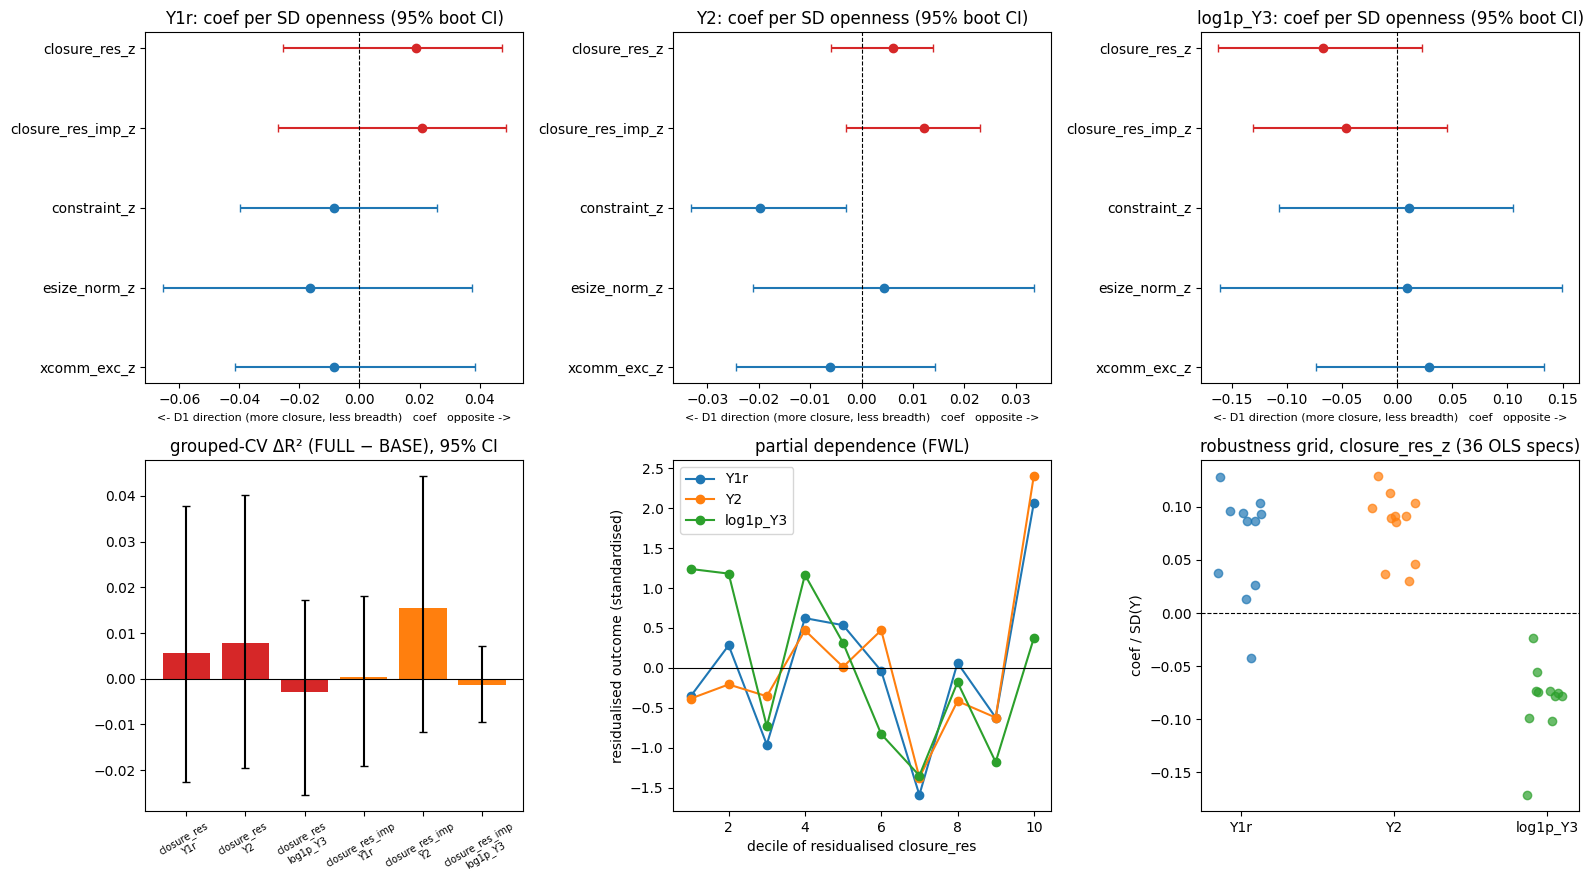

In [18]:
MEAS = ["closure_res_z", "closure_res_imp_z", "constraint_z", "esize_norm_z", "xcomm_exc_z"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
# row 1: forest plot of openness coefficients (per SD) per outcome, with bootstrap CIs
for j, y in enumerate(OUTCOMES):
    ax = axes[0, j]
    sub = coef[coef.outcome == y].set_index("openness").loc[MEAS]
    yy_ = np.arange(len(MEAS))[::-1]
    colors = ["C3" if m_.startswith("closure_res") else "C0" for m_ in MEAS]
    for yi, (_, r_), col in zip(yy_, sub.iterrows(), colors):
        ax.errorbar(r_.coef, yi, xerr=[[r_.coef - r_.ci_lo], [r_.ci_hi - r_.coef]], fmt="o", color=col, capsize=3)
    ax.axvline(0, color="k", lw=0.8, ls="--")
    ax.set_yticks(yy_, MEAS)
    ax.set_title(f"{y}: coef per SD openness (95% boot CI)")
    ax.set_xlabel("<- D1 direction (more closure, less breadth)   coef   opposite ->", fontsize=8)
# row 2 left: CV delta-R2 for the co-primary measures
ax = axes[1, 0]
sub = cv[(cv.model == "b_grouped_cv") & cv.openness.isin(["closure_res_z", "closure_res_imp_z"])].reset_index(drop=True)
xs = np.arange(len(sub))
ax.bar(xs, sub.delta_r2, color=["C3" if o == "closure_res_z" else "C1" for o in sub.openness])
ax.errorbar(xs, sub.delta_r2, yerr=[sub.delta_r2 - sub.ci_lo, sub.ci_hi - sub.delta_r2], fmt="none", ecolor="k", capsize=3)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(xs, [f"{o.replace('_z', '')}\n{y}" for o, y in zip(sub.openness, sub.outcome)], fontsize=7, rotation=30)
ax.set_title("grouped-CV ΔR² (FULL − BASE), 95% CI")
# row 2 middle: partial dependence (residualised outcome vs residualised closure_res deciles)
ax = axes[1, 1]
for y, gdf in pdp.groupby("outcome"):
    z = (gdf.y_resid_mean - gdf.y_resid_mean.mean()) / (gdf.y_resid_mean.std() or 1)
    ax.plot(gdf.decile, z, marker="o", label=y)
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("decile of residualised closure_res")
ax.set_ylabel("residualised outcome (standardised)")
ax.set_title("partial dependence (FWL)")
ax.legend()
# row 2 right: robustness grid coefficients (closure_res_z, OLS) in SD(Y) units
ax = axes[1, 2]
rr = rob[(rob.openness == "closure_res_z") & (rob.estimator == "OLS") & rob.coef.notna()].copy()
rr["coef_sd"] = rr.coef / rr.sd_y
for k_, y in enumerate(OUTCOMES):
    v = rr[rr.outcome == y].coef_sd
    ax.scatter(np.full(len(v), k_) + np.random.default_rng(k_).uniform(-0.15, 0.15, len(v)), v, alpha=0.7)
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xticks(range(len(OUTCOMES)), OUTCOMES)
ax.set_ylabel("coef / SD(Y)")
ax.set_title(f"robustness grid, closure_res_z ({len(rr)} OLS specs)")
plt.tight_layout()
plt.show()